# Last-Mile Delivery ETA Prediction
### Production-grade ML · Logistics Portfolio Project

**Problem:** Given a shipment's route, carrier, package, and environmental context at pickup time, predict the **delivery duration in minutes**.

**Why it matters:** Even a 10-minute improvement in ETA accuracy reduces customer inquiry rates, enables smarter re-routing, and cuts failed-delivery costs significantly in last-mile operations.

---
| Section | Content |
|---|---|
| 1 · Setup | Imports, config, seeds |
| 2 · Data | Synthetic but realistic dataset (25 k shipments) |
| 3 · EDA | Distributions, correlations, target deep-dive |
| 4 · Feature engineering | Traffic windows, route complexity, lag features |
| 5 · Preprocessing | ColumnTransformer pipeline |
| 6 · Modelling | Baseline → LightGBM → Optuna tuning |
| 7 · Evaluation | MAE, RMSE, MAPE, coverage, calibration |
| 8 · SHAP | Global importance + per-shipment waterfall |
| 9 · Error analysis | Residuals, failure modes, segment breakdown |
| 10 · Production notes | Deployment checklist & monitoring |


## 1 · Setup

In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 2.6 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Reproducibility
SEED = 42
np.random.seed(SEED)

# ── Plot style
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})
PALETTE = ["#4C6EF5", "#F76707", "#2F9E44", "#E03131", "#7950F2", "#1098AD"]

print(f"LightGBM {lgb.__version__} | SHAP {shap.__version__}")


LightGBM 4.6.0 | SHAP 0.51.0


## 2 · Synthetic Dataset

We generate **25,000 shipments** spanning 12 months with realistic distributions and a known data-generating process (DGP) so we can reason about model performance.

### Feature groups
| Group | Features |
|---|---|
| **Temporal** | pickup hour, day-of-week, month, is_weekend, is_rush_hour |
| **Route** | distance (km), stops before delivery, zone type |
| **Package** | weight, volume, requires_signature, delivery attempt |
| **Carrier** | carrier ID, service tier, carrier load % |
| **Environment** | traffic index, weather, temperature, wind speed |


In [ ]:
def generate_shipments(n: int = 25_000, seed: int = SEED) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    # ── Temporal
    pickup_dt   = pd.date_range("2023-01-01", periods=n, freq="20min") + pd.to_timedelta(rng.integers(0, 30, n), unit="min")
    hour        = pickup_dt.hour.values
    dow         = pickup_dt.dayofweek.values          # 0=Mon
    month       = pickup_dt.month.values
    is_weekend  = (dow >= 5).astype(int)
    is_rush     = ((hour >= 7) & (hour <= 9) | (hour >= 16) & (hour <= 19)).astype(int)

    # ── Route
    zone        = rng.choice(["urban", "suburban", "rural"], n, p=[0.55, 0.30, 0.15])
    dist_km     = np.where(zone == "urban",
                      rng.gamma(2, 4, n),          # ~8 km mean
                  np.where(zone == "suburban",
                      rng.gamma(3, 6, n),           # ~18 km mean
                      rng.gamma(4, 10, n)))          # ~40 km mean
    dist_km     = np.clip(dist_km, 0.5, 120)
    stops_before = rng.integers(0, 18, n)

    # ── Package
    weight_kg   = np.exp(rng.normal(1.5, 0.9, n))   # log-normal, realistic
    weight_kg   = np.clip(weight_kg, 0.1, 50)
    volume_l    = weight_kg * rng.uniform(0.5, 3.5, n)
    req_sig     = rng.binomial(1, 0.25, n)
    attempt     = rng.choice([1, 2, 3], n, p=[0.80, 0.15, 0.05])

    # ── Carrier
    carrier     = rng.choice(["DHL", "FedEx", "UPS", "Evri"], n, p=[0.28, 0.25, 0.27, 0.20])
    service     = rng.choice(["standard", "express", "same_day"], n, p=[0.60, 0.30, 0.10])
    load_pct    = rng.beta(5, 2, n) * 100            # skewed high (carriers usually busy)

    # ── Environment
    traffic     = (is_rush * rng.uniform(3, 5, n) +
                   (zone == "urban").astype(float) * rng.uniform(1, 3, n) +
                   rng.uniform(0, 2, n)).clip(0, 10)
    weather     = rng.choice(["clear", "rain", "snow", "fog"], n, p=[0.65, 0.22, 0.08, 0.05])
    temp_c      = rng.normal(12, 9, n)
    wind_kmh    = np.abs(rng.normal(15, 10, n))

    # ── Data-generating process (ground-truth delivery minutes)
    carrier_bias = {"DHL": 0, "FedEx": 5, "UPS": -3, "Evri": 12}
    service_mult = {"standard": 1.0, "express": 0.72, "same_day": 0.55}
    weather_add  = {"clear": 0, "rain": 8, "snow": 22, "fog": 12}
    zone_add     = {"urban": 5, "suburban": 2, "rural": -5}

    base = (
        dist_km * 2.8
        + stops_before * 2.5
        + traffic * 7.5
        + load_pct * 0.35
        + weight_kg * 0.4
        + volume_l * 0.1
        + req_sig * 4
        + (attempt - 1) * 18          # re-delivery adds delay
        + np.vectorize(carrier_bias.get)(carrier)
        + np.vectorize(weather_add.get)(weather)
        + np.vectorize(zone_add.get)(zone)
    ) * np.vectorize(service_mult.get)(service)

    noise     = rng.normal(0, base * 0.12)            # 12% proportional noise
    duration  = np.clip(base + noise, 10, 600)

    df = pd.DataFrame({
        "shipment_id":       [f"SHP-{i:06d}" for i in range(n)],
        "pickup_datetime":   pickup_dt,
        "pickup_hour":       hour,
        "pickup_dow":        dow,
        "pickup_month":      month,
        "is_weekend":        is_weekend,
        "is_rush_hour":      is_rush,
        "zone_type":         zone,
        "route_distance_km": dist_km.round(2),
        "stops_before":      stops_before,
        "weight_kg":         weight_kg.round(2),
        "volume_l":          volume_l.round(2),
        "requires_signature": req_sig,
        "delivery_attempt":  attempt,
        "carrier":           carrier,
        "service_type":      service,
        "carrier_load_pct":  load_pct.round(1),
        "traffic_index":     traffic.round(2),
        "weather":           weather,
        "temp_c":            temp_c.round(1),
        "wind_kmh":          wind_kmh.round(1),
        "delivery_minutes":  duration.round(1),
    })
    return df

df = generate_shipments(25_000)
print(f"Shape: {df.shape}")
print(f"Date range: {df.pickup_datetime.min().date()} → {df.pickup_datetime.max().date()}")
df.head()


Shape: (25000, 22)
Date range: 2023-01-01 → 2023-12-14


,shipment_id,pickup_datetime,pickup_hour,pickup_dow,pickup_month,is_weekend,is_rush_hour,zone_type,route_distance_km,stops_before,...,requires_signature,delivery_attempt,carrier,service_type,carrier_load_pct,traffic_index,weather,temp_c,wind_kmh,delivery_minutes
0,SHP-000000,2023-01-01 00:02:00,0,6,1,1,0,suburban,17.05,5,...,0,1,DHL,standard,92.5,1.68,clear,7.7,21.8,120.0
1,SHP-000001,2023-01-01 00:43:00,0,6,1,1,0,urban,3.14,9,...,0,2,UPS,standard,71.4,2.63,clear,16.4,2.5,95.0
2,SHP-000002,2023-01-01 00:59:00,0,6,1,1,0,urban,9.75,13,...,0,1,DHL,express,74.8,3.81,clear,1.7,33.5,92.5
3,SHP-000003,2023-01-01 01:13:00,1,6,1,1,0,rural,14.87,10,...,0,1,DHL,standard,85.7,0.18,clear,-7.9,5.3,80.0
4,SHP-000004,2023-01-01 01:32:00,1,6,1,1,0,suburban,16.05,3,...,0,1,FedEx,express,87.1,0.15,rain,5.5,5.7,72.6


In [ ]:
# Quick sanity check on the target
print(df["delivery_minutes"].describe().round(1))
print(f"\nNulls: {df.isnull().sum().sum()}")


count    25000.0
mean       117.0
std         48.2
min         22.0
25%         83.7
50%        108.8
75%        140.6
max        570.0
Name: delivery_minutes, dtype: float64

Nulls: 0


## 3 · Exploratory Data Analysis

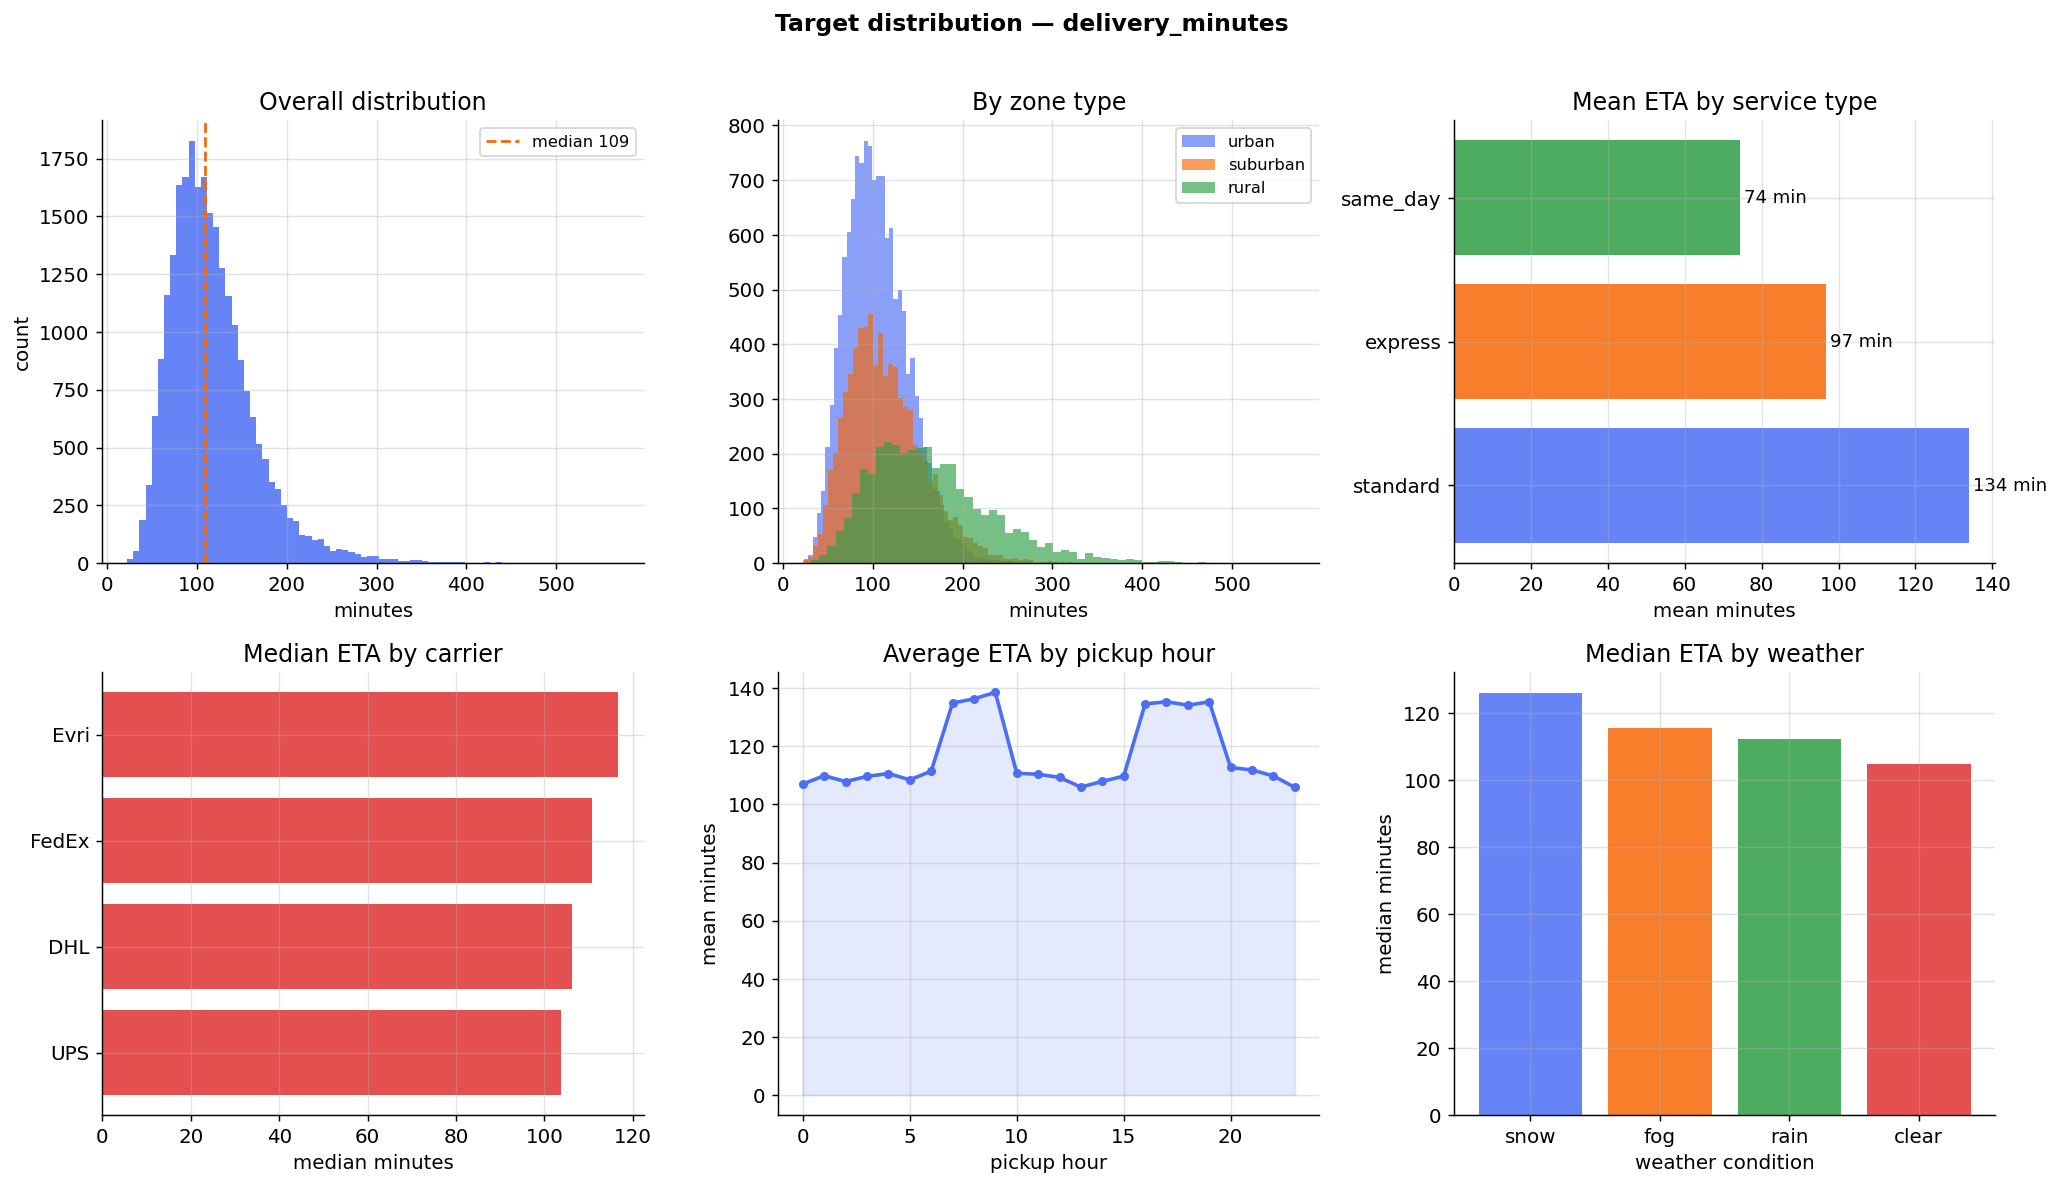

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Target distribution — delivery_minutes", fontsize=13, fontweight="bold", y=1.01)

# 3a. Overall distribution
ax = axes[0, 0]
ax.hist(df["delivery_minutes"], bins=80, color=PALETTE[0], alpha=0.85, edgecolor="none")
ax.set(xlabel="minutes", ylabel="count", title="Overall distribution")
ax.axvline(df["delivery_minutes"].median(), color=PALETTE[1], lw=1.5, ls="--", label=f"median {df['delivery_minutes'].median():.0f}")
ax.legend(fontsize=9)

# 3b. By zone
ax = axes[0, 1]
for i, zone in enumerate(["urban", "suburban", "rural"]):
    sub = df.loc[df.zone_type == zone, "delivery_minutes"]
    ax.hist(sub, bins=60, alpha=0.65, label=zone, color=PALETTE[i], edgecolor="none")
ax.set(xlabel="minutes", title="By zone type")
ax.legend(fontsize=9)

# 3c. By service type
ax = axes[0, 2]
order = ["standard", "express", "same_day"]
means = [df.loc[df.service_type == s, "delivery_minutes"].mean() for s in order]
ax.barh(order, means, color=PALETTE[:3], alpha=0.85)
ax.set(xlabel="mean minutes", title="Mean ETA by service type")
for i, v in enumerate(means):
    ax.text(v + 1, i, f"{v:.0f} min", va="center", fontsize=10)

# 3d. By carrier
ax = axes[1, 0]
carrier_med = df.groupby("carrier")["delivery_minutes"].median().sort_values()
ax.barh(carrier_med.index, carrier_med.values, color=PALETTE[3], alpha=0.85)
ax.set(xlabel="median minutes", title="Median ETA by carrier")

# 3e. Hourly pattern
ax = axes[1, 1]
hourly = df.groupby("pickup_hour")["delivery_minutes"].mean()
ax.plot(hourly.index, hourly.values, color=PALETTE[0], lw=2, marker="o", ms=4)
ax.fill_between(hourly.index, hourly.values, alpha=0.15, color=PALETTE[0])
ax.set(xlabel="pickup hour", ylabel="mean minutes", title="Average ETA by pickup hour")

# 3f. Weather impact
ax = axes[1, 2]
weather_med = df.groupby("weather")["delivery_minutes"].median().sort_values(ascending=False)
ax.bar(weather_med.index, weather_med.values, color=[PALETTE[i] for i in range(len(weather_med))], alpha=0.85)
ax.set(xlabel="weather condition", ylabel="median minutes", title="Median ETA by weather")

plt.tight_layout()
plt.show()


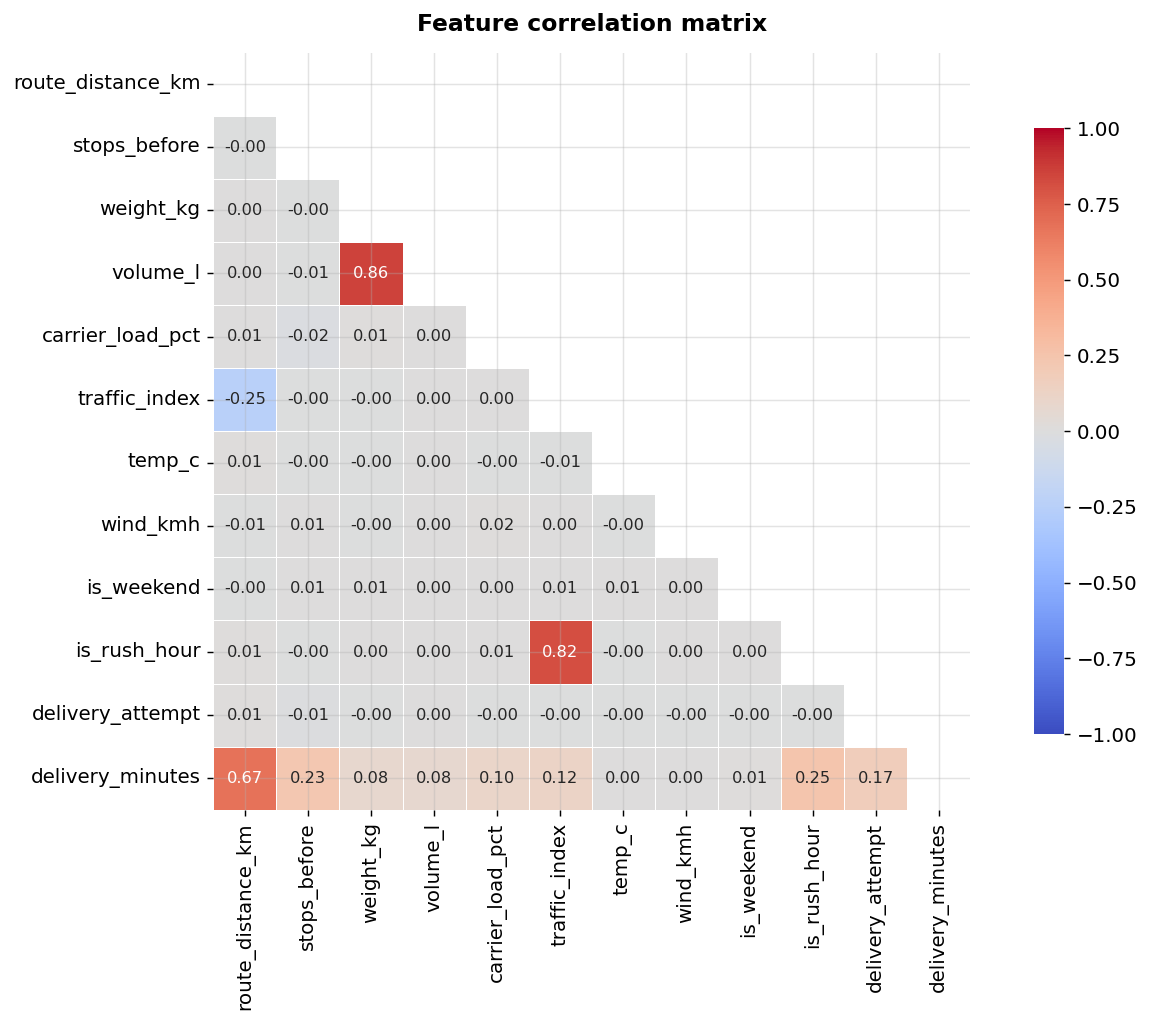

Top correlations with delivery_minutes:
route_distance_km    0.675
is_rush_hour         0.247
stops_before         0.230
delivery_attempt     0.174
traffic_index        0.121
carrier_load_pct     0.104
weight_kg            0.081
volume_l             0.076
is_weekend           0.009
wind_kmh             0.002
Name: delivery_minutes, dtype: float64


In [ ]:
# Correlation heatmap (numeric features only)
numeric_cols = ["route_distance_km", "stops_before", "weight_kg", "volume_l",
                "carrier_load_pct", "traffic_index", "temp_c", "wind_kmh",
                "is_weekend", "is_rush_hour", "delivery_attempt", "delivery_minutes"]

corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.4, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr["delivery_minutes"].drop("delivery_minutes").abs().sort_values(ascending=False)
print("Top correlations with delivery_minutes:")
print(target_corr.head(10).round(3))


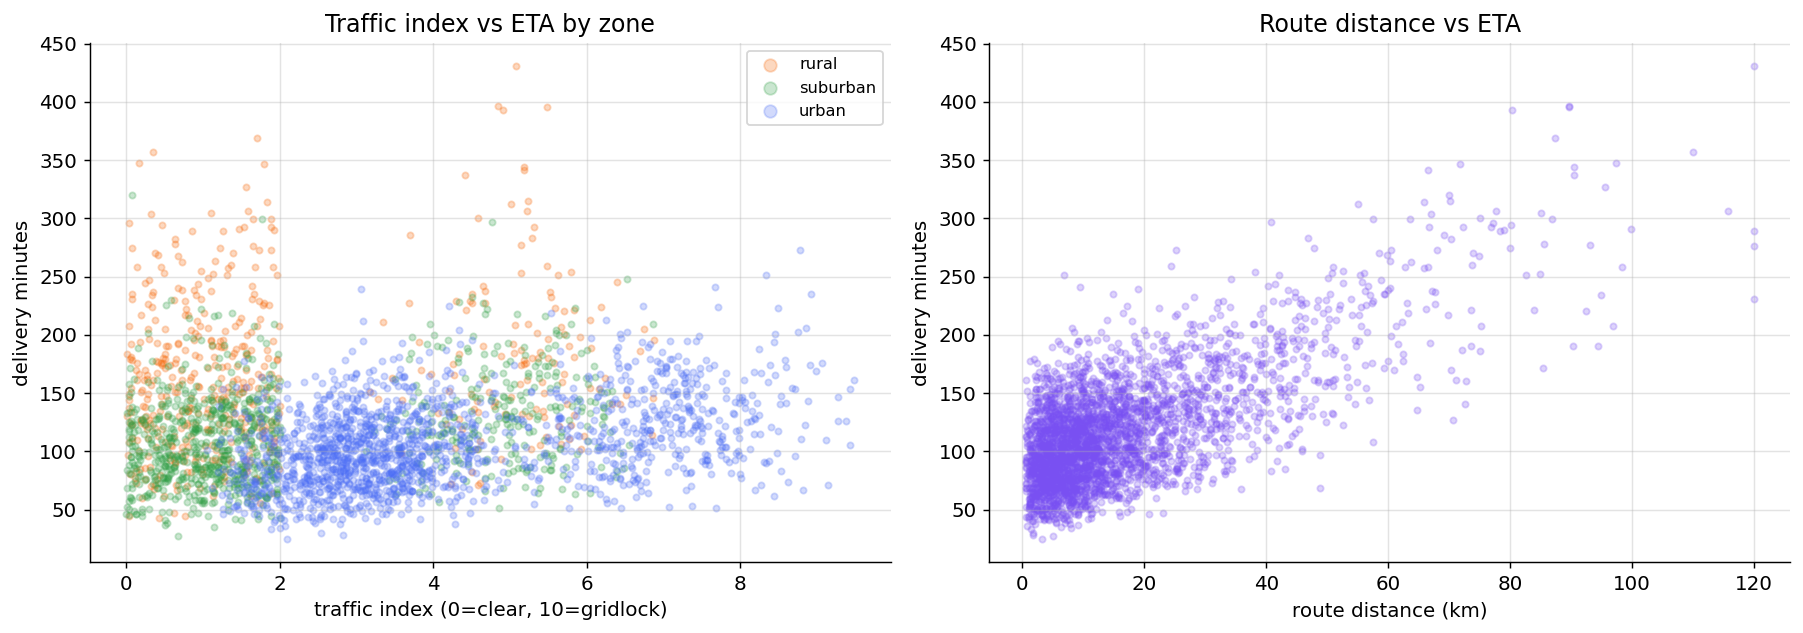

In [ ]:
# Traffic index vs delivery minutes — scatter with zone colour
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
zone_colors = {"urban": PALETTE[0], "suburban": PALETTE[2], "rural": PALETTE[1]}
for zone, grp in df.sample(3000, random_state=SEED).groupby("zone_type"):
    ax.scatter(grp["traffic_index"], grp["delivery_minutes"],
               alpha=0.25, s=12, color=zone_colors[zone], label=zone)
ax.set(xlabel="traffic index (0=clear, 10=gridlock)",
       ylabel="delivery minutes", title="Traffic index vs ETA by zone")
ax.legend(fontsize=9, markerscale=2)

# Distance vs delivery minutes
ax = axes[1]
ax.scatter(df.sample(3000, random_state=SEED)["route_distance_km"],
           df.sample(3000, random_state=SEED)["delivery_minutes"],
           alpha=0.25, s=12, color=PALETTE[4])
ax.set(xlabel="route distance (km)", ylabel="delivery minutes",
       title="Route distance vs ETA")

plt.tight_layout()
plt.show()


## 4 · Feature Engineering

Beyond the raw features we engineer several domain-informed signals:

| Feature | Rationale |
|---|---|
| `speed_potential` | distance ÷ expected base time — proxy for route efficiency |
| `traffic_load_interaction` | traffic × carrier load: compound congestion pressure |
| `package_density` | weight ÷ volume — affects handling time |
| `carrier_hist_delay` | historical median delay per carrier (computed from training data only, to prevent leakage) |
| `log_distance` | log transform to linearise the distance → time relationship |
| `hour_sin / hour_cos` | cyclical encoding of hour of day |
| `dow_sin / dow_cos` | cyclical encoding of day-of-week |
| `is_heavy` | binary flag: weight > 15 kg |
| `stops_x_load` | stop count × carrier load: busier carriers slow down with more stops |


In [ ]:
def engineer_features(df: pd.DataFrame, carrier_stats: dict | None = None, fit: bool = True):
    """
    Feature engineering pipeline.

    Parameters
    ----------
    df           : raw dataframe
    carrier_stats: dict of carrier → median delay (pass None to compute from df)
    fit          : if True, compute & return carrier_stats from df

    Returns
    -------
    df_out, carrier_stats
    """
    df = df.copy()

    # Cyclical time encoding
    df["hour_sin"] = np.sin(2 * np.pi * df["pickup_hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["pickup_hour"] / 24)
    df["dow_sin"]  = np.sin(2 * np.pi * df["pickup_dow"] / 7)
    df["dow_cos"]  = np.cos(2 * np.pi * df["pickup_dow"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["pickup_month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["pickup_month"] / 12)

    # Log-transform skewed continuous features
    df["log_distance"]  = np.log1p(df["route_distance_km"])
    df["log_weight"]    = np.log1p(df["weight_kg"])
    df["log_volume"]    = np.log1p(df["volume_l"])

    # Package density (handling complexity proxy)
    df["package_density"] = df["weight_kg"] / (df["volume_l"] + 1e-6)

    # Interaction terms (domain knowledge)
    df["traffic_load_interaction"] = df["traffic_index"] * df["carrier_load_pct"] / 100
    df["stops_x_load"]             = df["stops_before"] * df["carrier_load_pct"] / 100
    df["dist_x_traffic"]           = df["log_distance"] * df["traffic_index"]

    # Binary flags
    df["is_heavy"]       = (df["weight_kg"] > 15).astype(int)
    df["is_redelivery"]  = (df["delivery_attempt"] > 1).astype(int)
    df["is_same_day"]    = (df["service_type"] == "same_day").astype(int)

    # Carrier historical median delay (target-encoding, no leakage if fit on train)
    if fit:
        carrier_stats = df.groupby("carrier")["delivery_minutes"].median().to_dict()
    df["carrier_hist_delay"] = df["carrier"].map(carrier_stats)

    return df, carrier_stats


# Apply to full dataset for EDA purposes (leakage is fine here; we'll redo properly in pipeline)
df_feat, carrier_stats_full = engineer_features(df, fit=True)

new_features = ["hour_sin", "hour_cos", "log_distance", "package_density",
                "traffic_load_interaction", "stops_x_load", "carrier_hist_delay"]
print("New engineered features preview:")
df_feat[new_features].describe().round(3)


New engineered features preview:


,hour_sin,hour_cos,log_distance,package_density,traffic_load_interaction,stops_x_load,carrier_hist_delay
count,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000
mean,-0.000,0.001,2.483,0.650,2.335,6.044,108.823
std,0.707,0.707,0.840,0.390,1.706,4.001,4.711
min,-1.000,-1.000,0.405,0.285,0.000,0.000,103.700
25%,-0.707,-0.707,1.901,0.362,0.981,2.672,103.700
50%,0.000,0.000,2.478,0.502,1.989,5.712,106.300
75%,0.707,0.707,3.068,0.808,3.339,9.064,110.800
max,1.000,1.000,4.796,2.008,9.051,16.830,116.650


## 5 · Preprocessing Pipeline

In [ ]:
from sklearn.model_selection import train_test_split

TARGET = "delivery_minutes"
DROP   = ["shipment_id", "pickup_datetime", "pickup_hour", "pickup_dow",
          "pickup_month"]   # replaced by cyclical encodings

CATEGORICALS = ["zone_type", "carrier", "service_type", "weather"]
NUMERICS = [c for c in df_feat.columns
            if c not in CATEGORICALS + DROP + [TARGET]]

print(f"Numeric features  : {len(NUMERICS)}")
print(f"Categorical features: {len(CATEGORICALS)}")
print(f"Target            : {TARGET}")


Numeric features  : 29
Categorical features: 4
Target            : delivery_minutes


In [ ]:
# ── Train / Validation / Test split  (70 / 15 / 15)
# We split by time to prevent future leakage
df_sorted = df_feat.sort_values("pickup_datetime").reset_index(drop=True)
n = len(df_sorted)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

train_raw = df_sorted.iloc[:train_end].copy()
val_raw   = df_sorted.iloc[train_end:val_end].copy()
test_raw  = df_sorted.iloc[val_end:].copy()

# Re-engineer features with training-only carrier stats (no leakage)
train_df, carrier_stats_train = engineer_features(train_raw, fit=True)
val_df,   _                   = engineer_features(val_raw,   carrier_stats=carrier_stats_train, fit=False)
test_df,  _                   = engineer_features(test_raw,  carrier_stats=carrier_stats_train, fit=False)

X_train, y_train = train_df[NUMERICS + CATEGORICALS], train_df[TARGET]
X_val,   y_val   = val_df[NUMERICS + CATEGORICALS],   val_df[TARGET]
X_test,  y_test  = test_df[NUMERICS + CATEGORICALS],  test_df[TARGET]

# LightGBM requires category dtype for categorical features
for col in CATEGORICALS:
    cats = X_train[col].unique().tolist()
    for X in [X_train, X_val, X_test]:
        X[col] = pd.Categorical(X[col], categories=cats)

print(f"Train : {X_train.shape[0]:,} | Val : {X_val.shape[0]:,} | Test : {X_test.shape[0]:,}")


Train : 17,500 | Val : 3,750 | Test : 3,750


In [ ]:
# Preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERICS),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICALS),
    ],
    remainder="drop",
)
preprocessor.fit(X_train)

X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)
feature_names = NUMERICS + CATEGORICALS
print(f"Feature matrix shape: {X_train_t.shape}")


Feature matrix shape: (17500, 33)


## 6 · Modelling

We follow a progressive model ladder:

1. **Median baseline** — predict the training median for every shipment
2. **Ridge regression** — linear baseline  
3. **LightGBM (default params)** — to measure the non-linear gain
4. **LightGBM (Optuna-tuned)** — 50-trial Bayesian search


In [ ]:
def regression_metrics(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{label:<25}  MAE={mae:6.2f} min   RMSE={rmse:6.2f} min   MAPE={mape:5.2f}%")
    return {"label": label, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []


In [ ]:
# ── Model 1: Median baseline
median_pred = np.full(len(y_test), y_train.median())
results.append(regression_metrics(y_test, median_pred, "Median baseline"))


Median baseline            MAE= 35.49 min   RMSE= 48.65 min   MAPE=32.93%


In [ ]:
# ── Model 2: Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_t, y_train)
ridge_pred = ridge.predict(X_test_t)
results.append(regression_metrics(y_test, ridge_pred, "Ridge regression"))


Ridge regression           MAE= 12.58 min   RMSE= 16.76 min   MAPE=11.62%


In [ ]:
# ── Model 3: LightGBM default
lgb_default = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=127,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
lgb_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
    categorical_feature=CATEGORICALS,
)
lgb_default_pred = lgb_default.predict(X_test)
results.append(regression_metrics(y_test, lgb_default_pred, "LightGBM default"))
print(f"Best iteration: {lgb_default.best_iteration_}")


LightGBM default           MAE= 11.57 min   RMSE= 15.65 min   MAPE=10.29%
Best iteration: 137


In [ ]:
# ── Model 4: LightGBM + Optuna tuning (50 trials)
def objective(trial):
    params = {
        "n_estimators":       trial.suggest_int("n_estimators", 300, 2000),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves":         trial.suggest_int("num_leaves", 31, 255),
        "min_child_samples":  trial.suggest_int("min_child_samples", 10, 100),
        "feature_fraction":   trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction":   trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq":       trial.suggest_int("bagging_freq", 1, 7),
        "reg_alpha":          trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":         trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "random_state":       SEED,
        "n_jobs":             -1,
        "verbose":            -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
        categorical_feature=CATEGORICALS,
    )
    return mean_absolute_error(y_val, model.predict(X_val))

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest val MAE: {study.best_value:.4f} min")
print(f"Best params: {study.best_params}")


  0%|          | 0/50 [00:00<?, ?it/s]


Best val MAE: 11.8076 min
Best params: {'n_estimators': 846, 'learning_rate': 0.010091826113129084, 'num_leaves': 55, 'min_child_samples': 62, 'feature_fraction': 0.6351369265018405, 'bagging_fraction': 0.669907758188321, 'bagging_freq': 1, 'reg_alpha': 0.002422097779130147, 'reg_lambda': 0.055361326892126764}


In [ ]:
# ── Retrain tuned model on train + val
best_params = {**study.best_params, "random_state": SEED, "n_jobs": -1, "verbose": -1}
lgb_tuned = lgb.LGBMRegressor(**best_params)
lgb_tuned.fit(
    pd.concat([X_train, X_val]),
    pd.concat([y_train, y_val]),
    categorical_feature=CATEGORICALS,
)
lgb_tuned_pred = lgb_tuned.predict(X_test)
results.append(regression_metrics(y_test, lgb_tuned_pred, "LightGBM tuned"))


LightGBM tuned             MAE= 11.26 min   RMSE= 15.28 min   MAPE=10.02%


## 7 · Evaluation

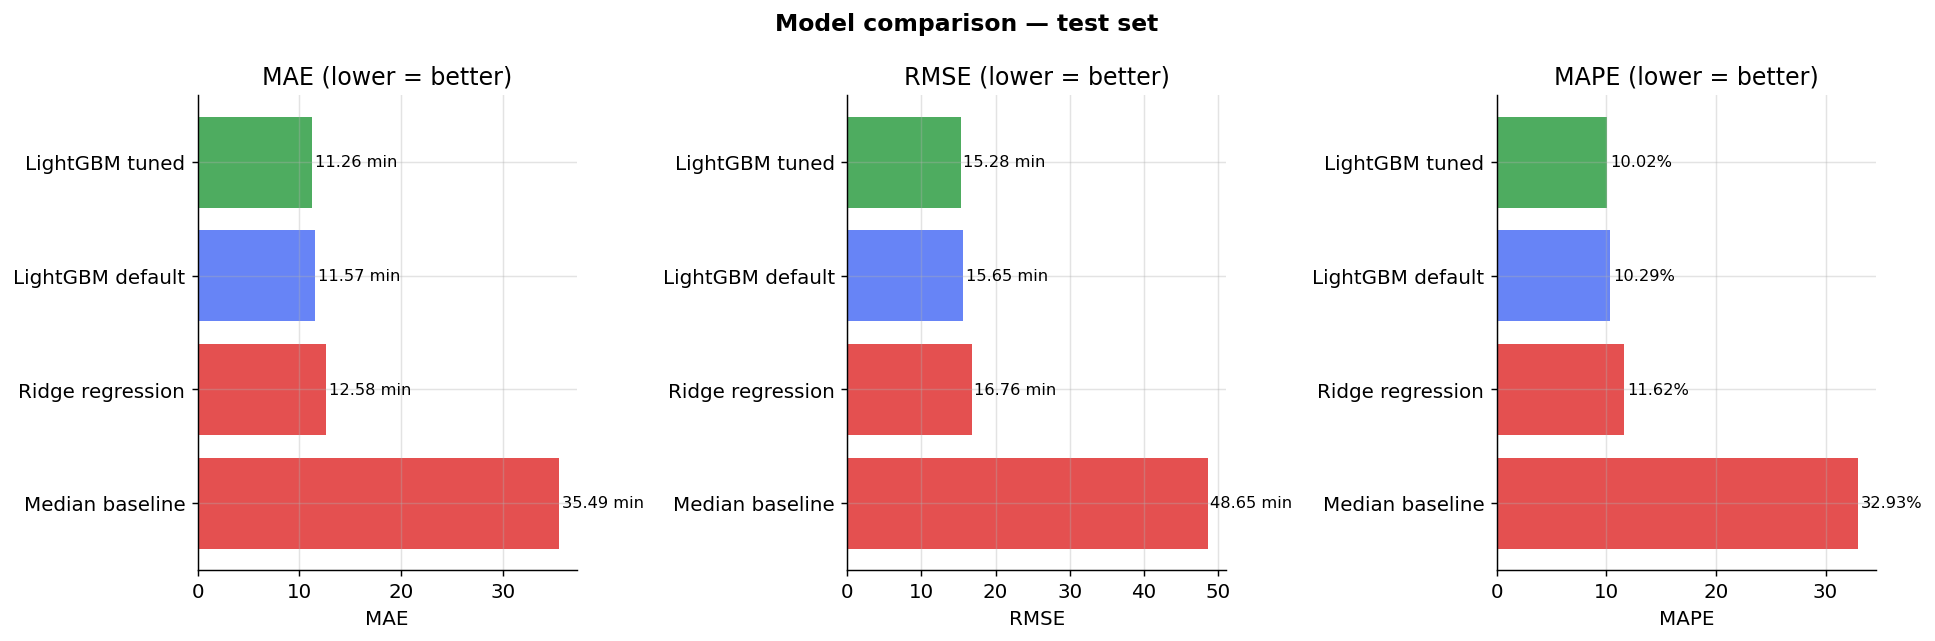


Final model comparison:
                     MAE    RMSE    MAPE
label                                   
Median baseline   35.490  48.650  32.931
Ridge regression  12.582  16.765  11.617
LightGBM default  11.568  15.649  10.292
LightGBM tuned    11.264  15.275  10.018


In [ ]:
# ── Model comparison bar chart
results_df = pd.DataFrame(results)
fig, axes  = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model comparison — test set", fontsize=13, fontweight="bold")

for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE"]):
    colors = [PALETTE[3] if i < 2 else PALETTE[0] if i == 2 else PALETTE[2]
              for i in range(len(results_df))]
    bars = ax.barh(results_df["label"], results_df[metric], color=colors, alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_title(f"{metric} (lower = better)")
    for bar, val in zip(bars, results_df[metric]):
        unit = "%" if metric == "MAPE" else " min"
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}{unit}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print("\nFinal model comparison:")
print(results_df.set_index("label").round(3).to_string())


In [ ]:
# ── Prediction interval coverage (80% and 95%)
#    Use quantile regression via LightGBM's built-in quantile loss

def fit_quantile_model(alpha, X_tr, y_tr, X_te):
    m = lgb.LGBMRegressor(
        objective="quantile",
        alpha=alpha,
        **{k: v for k, v in best_params.items() if k not in ["random_state","n_jobs","verbose"]},
        random_state=SEED, n_jobs=-1, verbose=-1
    )
    m.fit(pd.concat([X_tr, X_val]), pd.concat([y_tr, y_val]),
          categorical_feature=CATEGORICALS)
    return m.predict(X_te)

print("Fitting quantile models for prediction intervals…")
lo80  = fit_quantile_model(0.10, X_train, y_train, X_test)
hi80  = fit_quantile_model(0.90, X_train, y_train, X_test)
lo95  = fit_quantile_model(0.025, X_train, y_train, X_test)
hi95  = fit_quantile_model(0.975, X_train, y_train, X_test)

cov80 = np.mean((y_test.values >= lo80) & (y_test.values <= hi80))
cov95 = np.mean((y_test.values >= lo95) & (y_test.values <= hi95))
width80 = np.median(hi80 - lo80)
width95 = np.median(hi95 - lo95)

print(f"80% PI coverage: {cov80:.1%}  (target 80%)  |  median width: {width80:.1f} min")
print(f"95% PI coverage: {cov95:.1%}  (target 95%)  |  median width: {width95:.1f} min")


Fitting quantile models for prediction intervals…
80% PI coverage: 76.0%  (target 80%)  |  median width: 30.5 min
95% PI coverage: 92.3%  (target 95%)  |  median width: 50.8 min


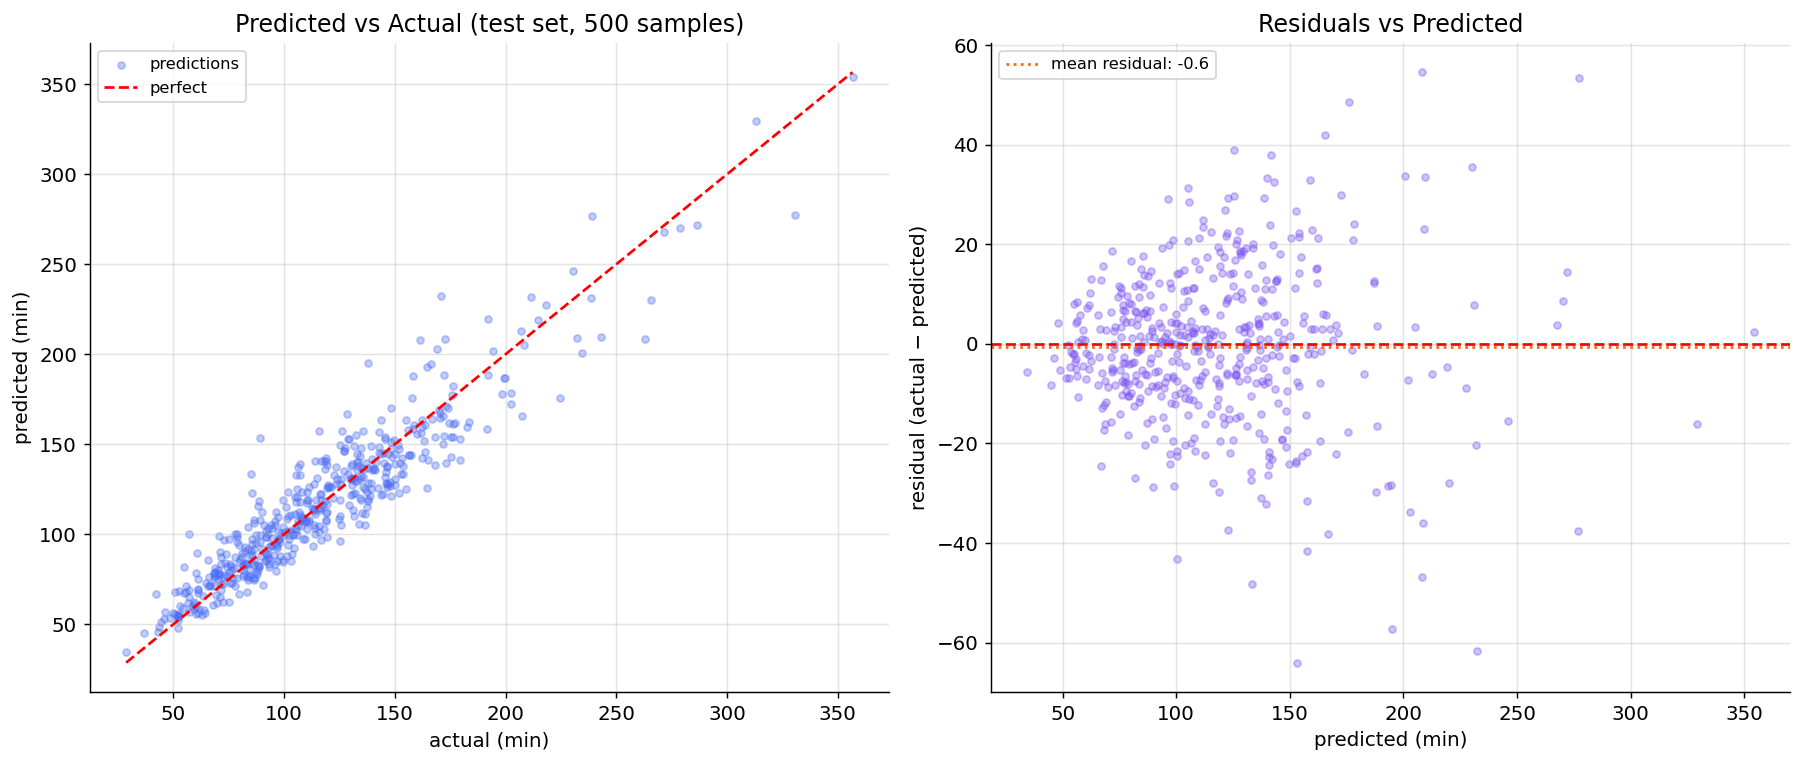

In [ ]:
# ── Prediction vs actual scatter with prediction intervals
sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_s   = y_test.values[sample_idx]
yhat_s = lgb_tuned_pred[sample_idx]
lo_s  = lo80[sample_idx]
hi_s  = hi80[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter
ax = axes[0]
ax.scatter(y_s, yhat_s, alpha=0.35, s=15, color=PALETTE[0], label="predictions")
mn, mx = y_s.min(), y_s.max()
ax.plot([mn, mx], [mn, mx], "r--", lw=1.5, label="perfect")
ax.set(xlabel="actual (min)", ylabel="predicted (min)", title="Predicted vs Actual (test set, 500 samples)")
ax.legend(fontsize=9)

# Residuals vs predicted
ax = axes[1]
residuals = y_s - yhat_s
ax.scatter(yhat_s, residuals, alpha=0.35, s=15, color=PALETTE[4])
ax.axhline(0, color="red", lw=1.5, ls="--")
ax.axhline(residuals.mean(), color=PALETTE[1], lw=1.5, ls=":", label=f"mean residual: {residuals.mean():.1f}")
ax.set(xlabel="predicted (min)", ylabel="residual (actual − predicted)",
       title="Residuals vs Predicted")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 8 · SHAP Explainability

SHAP (SHapley Additive exPlanations) decomposes every prediction into a sum of feature contributions. This is critical for production logistics models where ops teams need to understand *why* a particular ETA was predicted.


In [ ]:
# Compute SHAP values on a 2000-sample subset (faster)
shap_sample = X_test.sample(2000, random_state=SEED)
explainer   = shap.TreeExplainer(lgb_tuned)
shap_values = explainer.shap_values(shap_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Expected value (base rate): {explainer.expected_value:.2f} min")


SHAP values shape: (2000, 33)
Expected value (base rate): 116.99 min


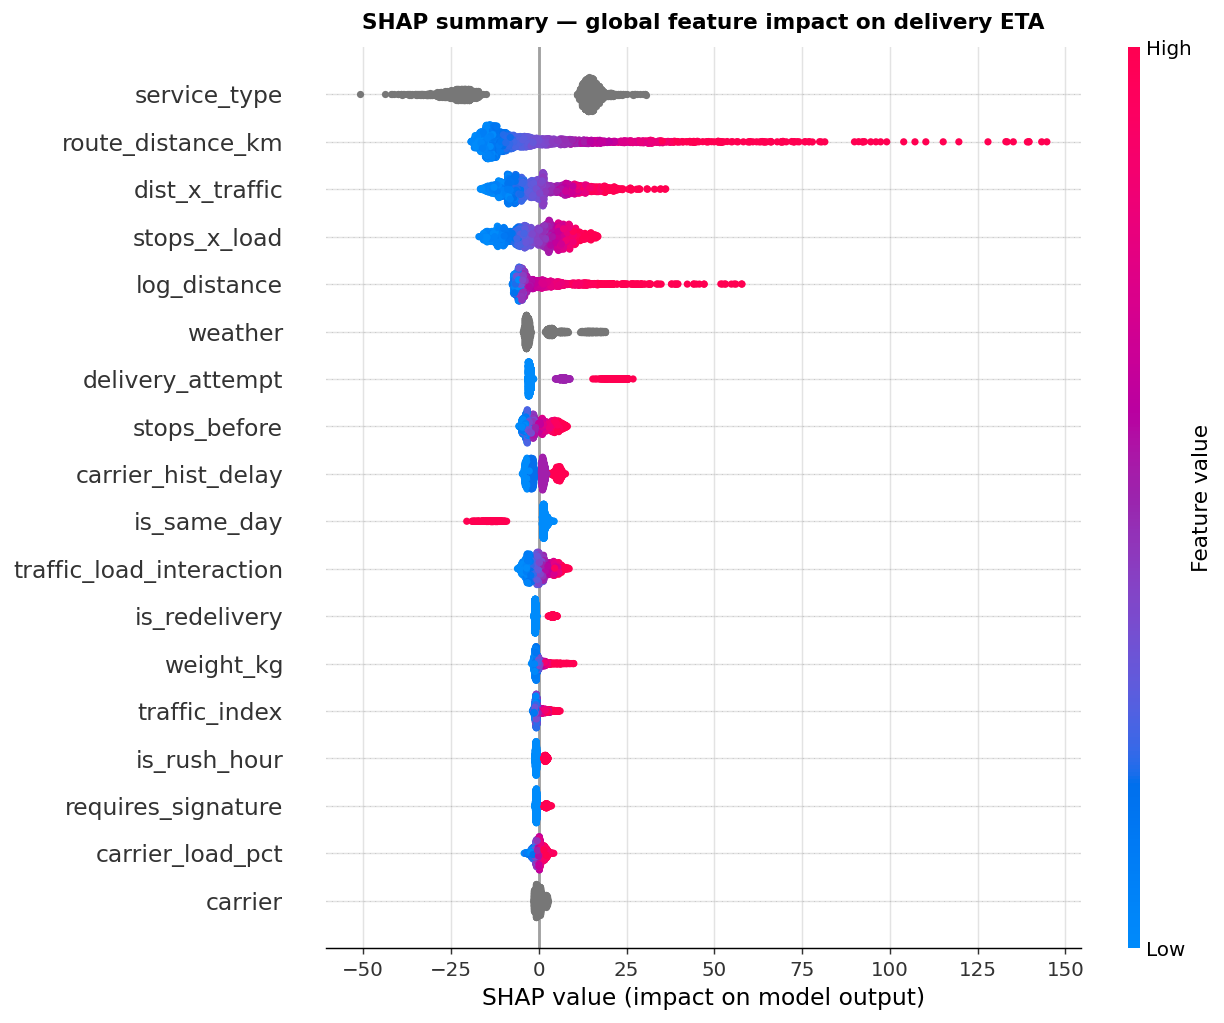

In [ ]:
# ── Global SHAP summary (beeswarm)
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=shap_sample.columns.tolist(),
    show=False,
    max_display=18,
    plot_size=None,
)
plt.title("SHAP summary — global feature impact on delivery ETA", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.show()


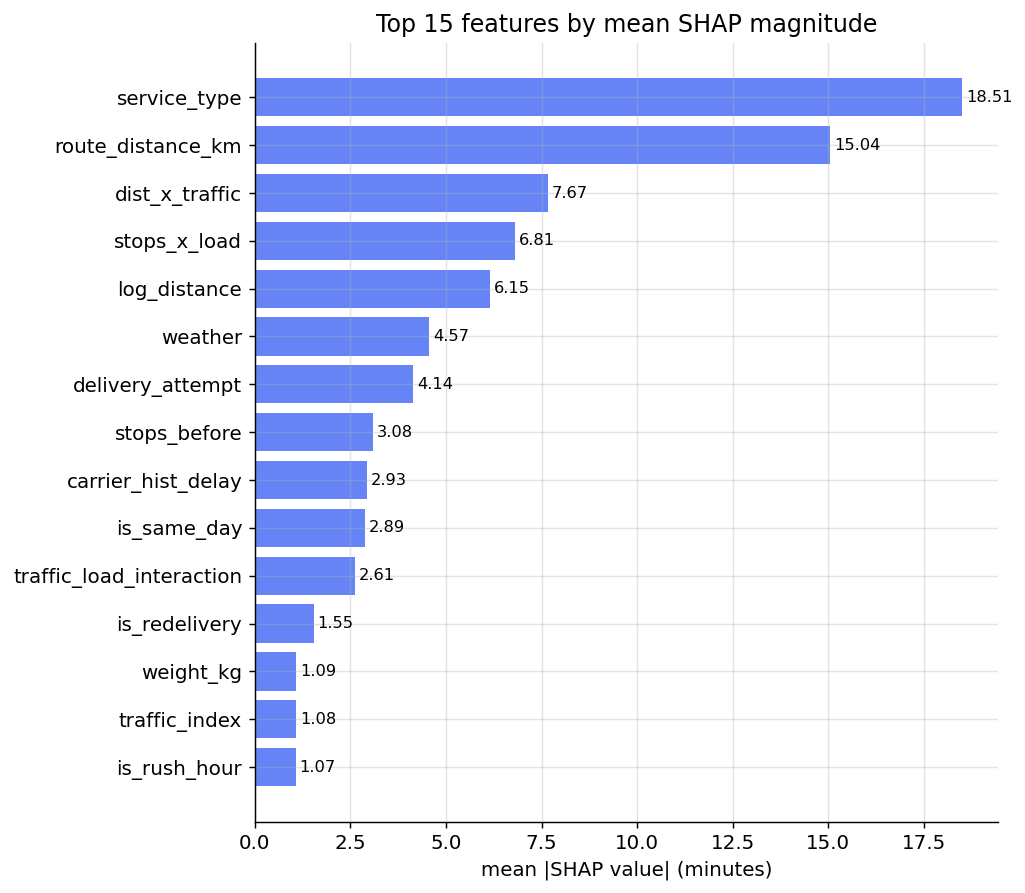

In [ ]:
# ── SHAP bar chart (mean |SHAP|)
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=shap_sample.columns
).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(mean_shap.index, mean_shap.values, color=PALETTE[0], alpha=0.85)
ax.set(xlabel="mean |SHAP value| (minutes)", title="Top 15 features by mean SHAP magnitude")
for bar, val in zip(bars, mean_shap.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


Shipment index    : 321
Actual ETA        : 87.2 min
Predicted ETA     : 79.0 min
Absolute error    : 8.2 min


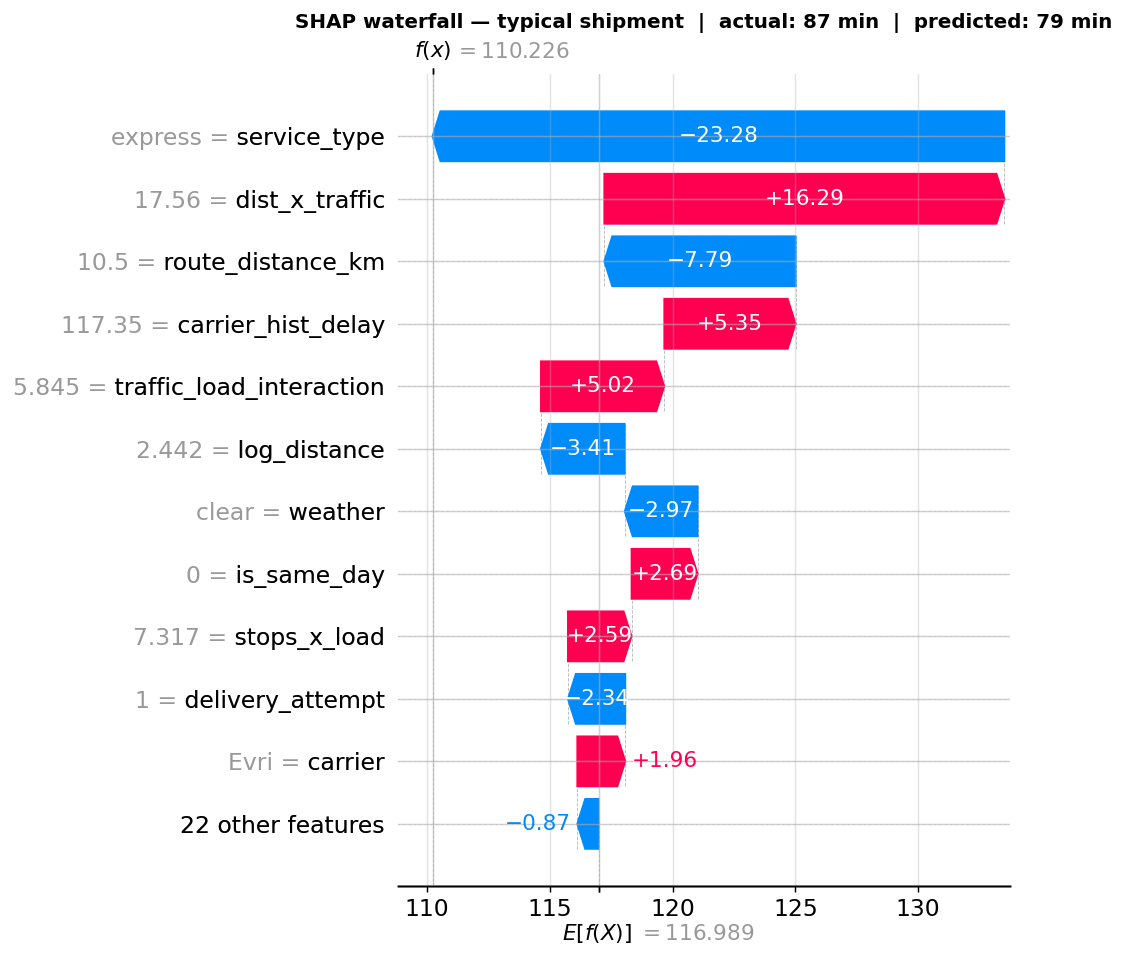

In [ ]:
# ── Per-shipment waterfall — best case, worst case, typical
y_test_arr   = y_test.values
lgb_test_arr = lgb_tuned.predict(X_test)
errors       = np.abs(y_test_arr - lgb_test_arr)

# Re-compute SHAP on full test set for waterfall
full_shap_sample = X_test.sample(500, random_state=SEED)
full_shap_vals   = explainer.shap_values(full_shap_sample)

# Pick: median error shipment
median_idx = np.argsort(errors[:len(full_shap_sample)])[len(full_shap_sample) // 2]

print(f"Shipment index    : {median_idx}")
print(f"Actual ETA        : {y_test_arr[median_idx]:.1f} min")
print(f"Predicted ETA     : {lgb_test_arr[median_idx]:.1f} min")
print(f"Absolute error    : {errors[median_idx]:.1f} min")

expl_obj = shap.Explanation(
    values          = full_shap_vals[median_idx],
    base_values     = explainer.expected_value,
    data            = full_shap_sample.iloc[median_idx].values,
    feature_names   = full_shap_sample.columns.tolist(),
)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(expl_obj, max_display=12, show=False)
plt.title(f"SHAP waterfall — typical shipment  |  actual: {y_test_arr[median_idx]:.0f} min  |  predicted: {lgb_test_arr[median_idx]:.0f} min",
          fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


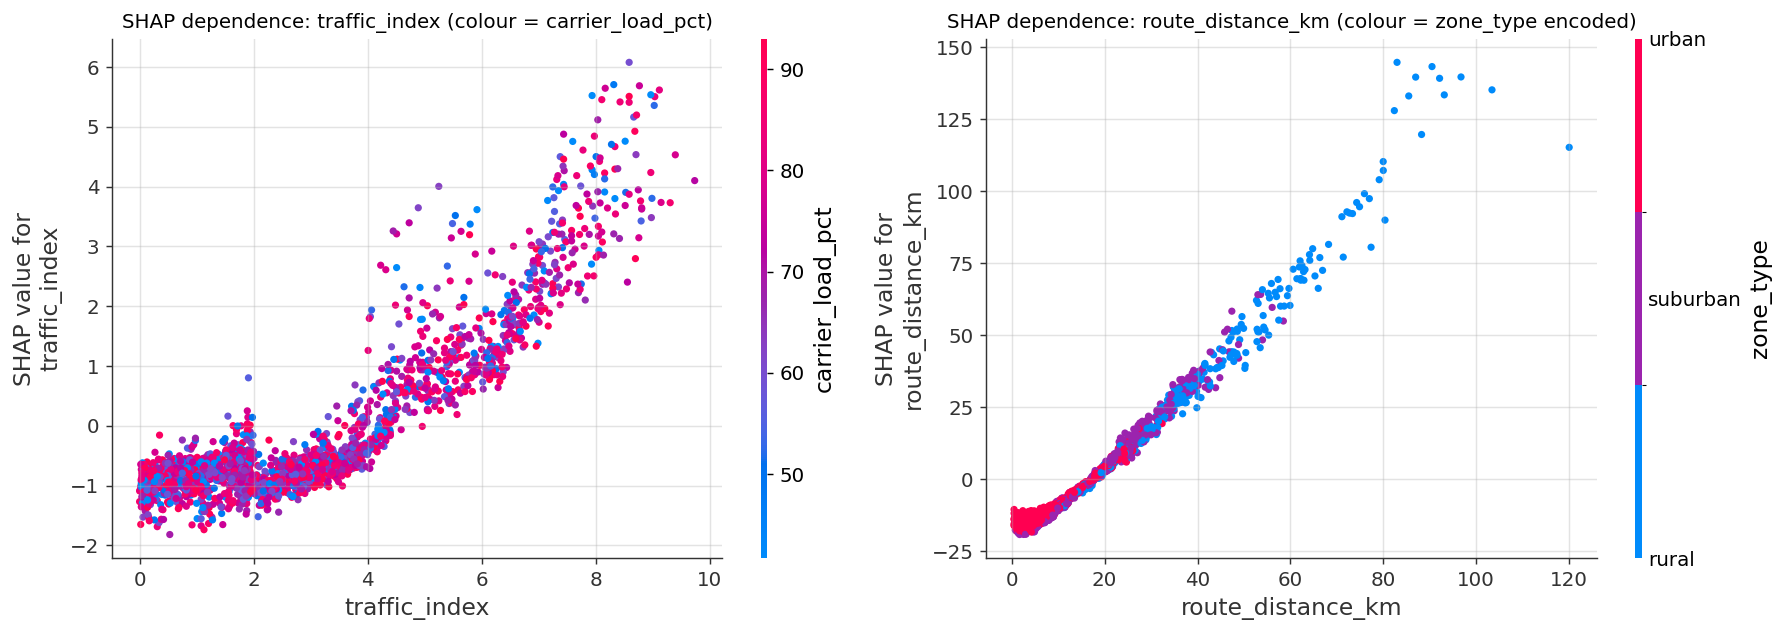

In [ ]:
# ── SHAP dependence: traffic_index (most impactful continuous feature)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

traffic_idx_col = shap_sample.columns.tolist().index("traffic_index")
load_idx_col    = shap_sample.columns.tolist().index("carrier_load_pct")

shap.dependence_plot(
    "traffic_index",
    shap_values, shap_sample,
    interaction_index="carrier_load_pct",
    ax=axes[0], show=False
)
axes[0].set_title("SHAP dependence: traffic_index (colour = carrier_load_pct)", fontsize=11)

shap.dependence_plot(
    "route_distance_km",
    shap_values, shap_sample,
    interaction_index="zone_type",
    ax=axes[1], show=False
)
axes[1].set_title("SHAP dependence: route_distance_km (colour = zone_type encoded)", fontsize=11)

plt.tight_layout()
plt.show()


## 9 · Error Analysis

In [ ]:
# Build a test result dataframe for slicing
test_results = test_df.copy()
test_results["predicted"]     = lgb_tuned.predict(X_test)
test_results["residual"]      = test_results["delivery_minutes"] - test_results["predicted"]
test_results["abs_error"]     = test_results["residual"].abs()
test_results["pct_error"]     = test_results["abs_error"] / test_results["delivery_minutes"] * 100
test_results["error_bucket"]  = pd.cut(test_results["abs_error"], [0, 5, 10, 20, 40, 9999],
                                        labels=["≤5", "5–10", "10–20", "20–40", ">40"])

print("Error distribution by bucket (% of test shipments):")
print((test_results["error_bucket"].value_counts(normalize=True).sort_index() * 100).round(1))


Error distribution by bucket (% of test shipments):
error_bucket
≤5       30.7
5–10     25.1
10–20    29.1
20–40    13.0
>40       2.1
Name: proportion, dtype: float64


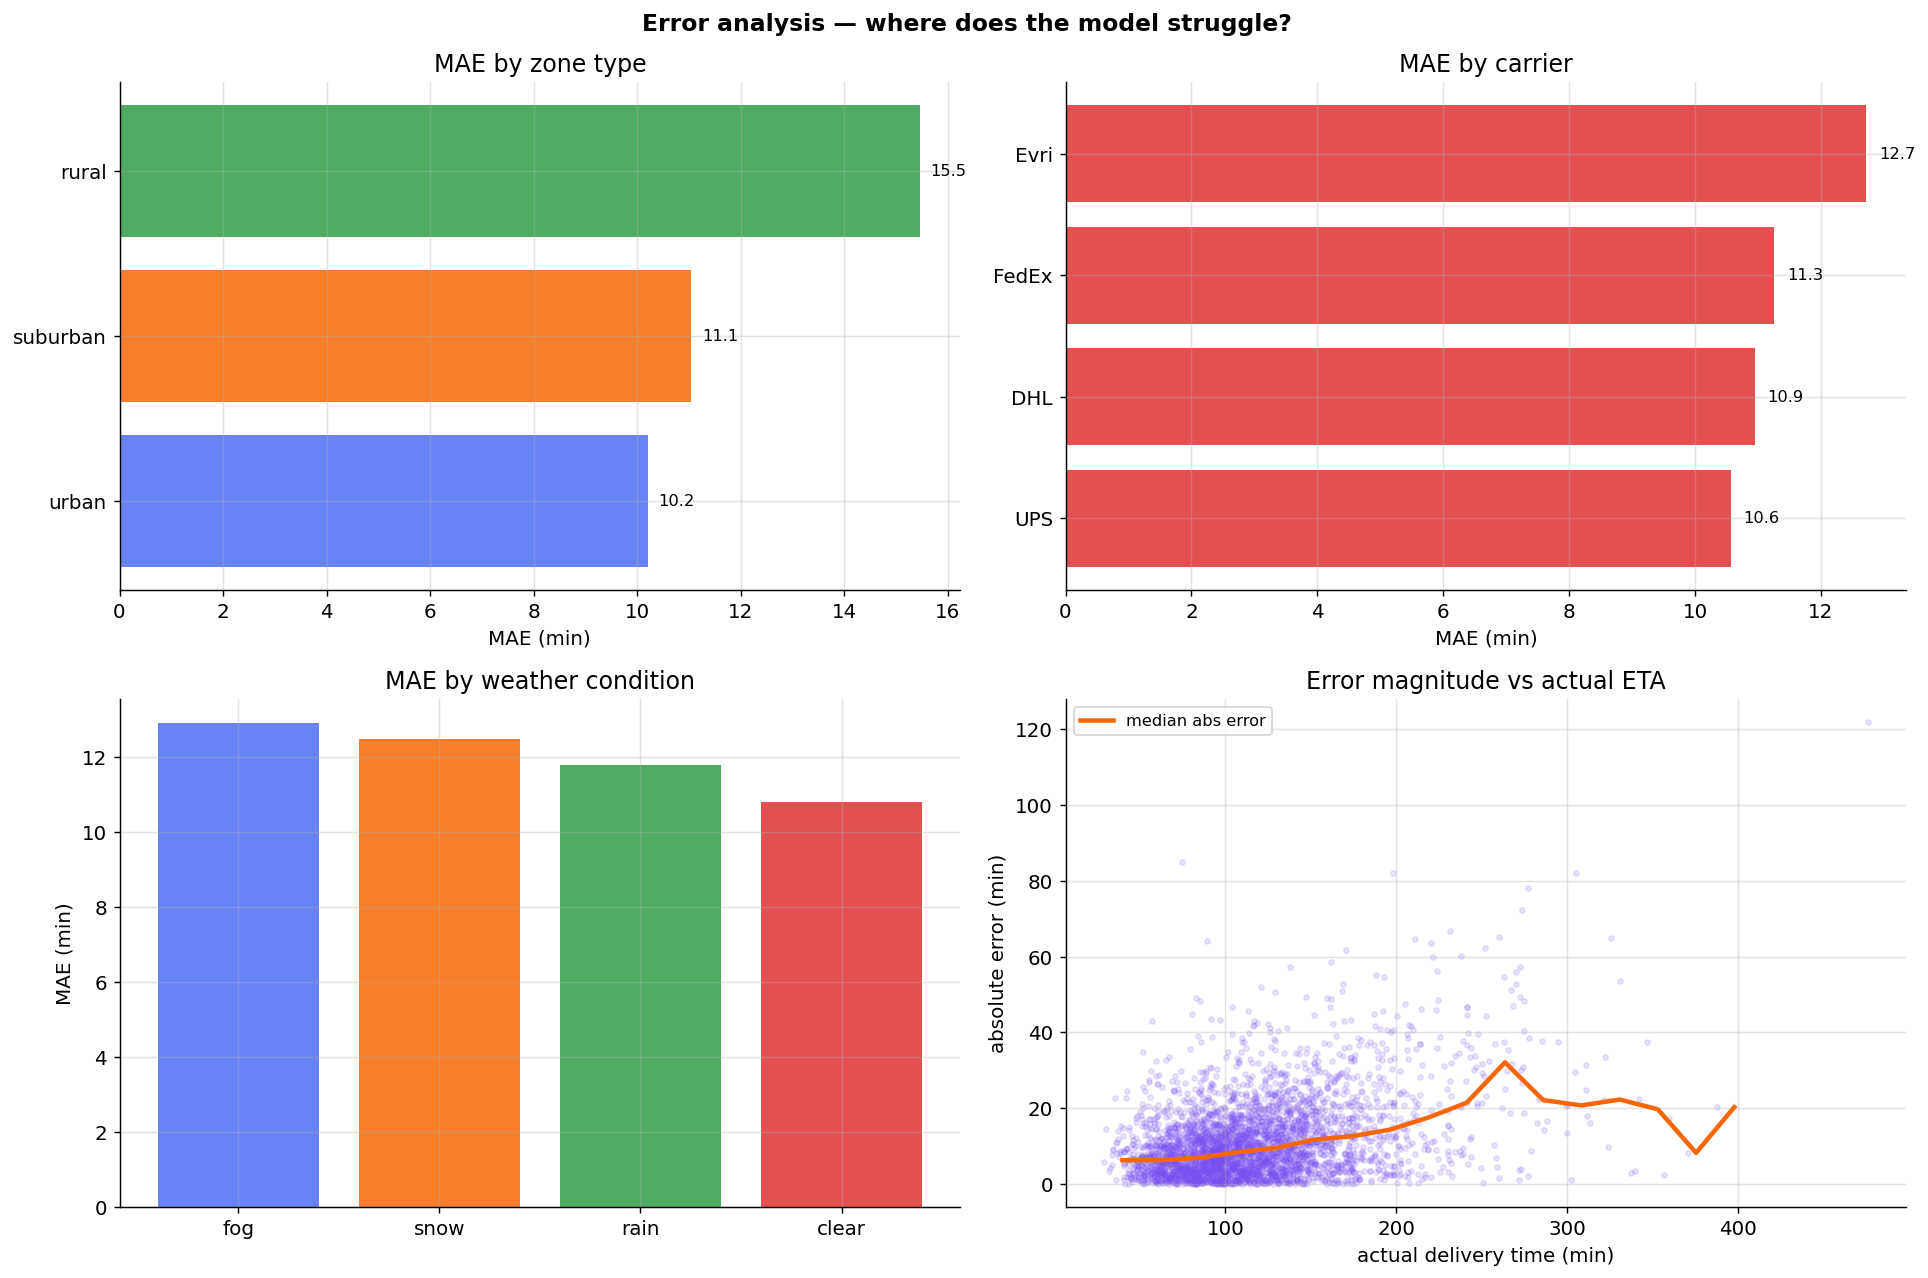

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Error analysis — where does the model struggle?", fontsize=13, fontweight="bold")

# 9a. MAE by zone
ax = axes[0, 0]
zone_mae = test_results.groupby("zone_type")["abs_error"].mean().sort_values()
ax.barh(zone_mae.index, zone_mae.values, color=PALETTE[:3], alpha=0.85)
ax.set(xlabel="MAE (min)", title="MAE by zone type")
for i, v in enumerate(zone_mae.values):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)

# 9b. MAE by carrier
ax = axes[0, 1]
carrier_mae = test_results.groupby("carrier")["abs_error"].mean().sort_values()
ax.barh(carrier_mae.index, carrier_mae.values, color=PALETTE[3], alpha=0.85)
ax.set(xlabel="MAE (min)", title="MAE by carrier")
for i, v in enumerate(carrier_mae.values):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)

# 9c. MAE by weather
ax = axes[1, 0]
weather_mae = test_results.groupby("weather")["abs_error"].mean().sort_values(ascending=False)
ax.bar(weather_mae.index, weather_mae.values,
       color=[PALETTE[i] for i in range(len(weather_mae))], alpha=0.85)
ax.set(ylabel="MAE (min)", title="MAE by weather condition")

# 9d. Error vs actual delivery time
ax = axes[1, 1]
ax.scatter(test_results["delivery_minutes"], test_results["abs_error"],
           alpha=0.15, s=8, color=PALETTE[4])
# Smooth trend
bins = pd.cut(test_results["delivery_minutes"], 20)
trend = test_results.groupby(bins)["abs_error"].median()
bin_mids = [b.mid for b in trend.index]
ax.plot(bin_mids, trend.values, color=PALETTE[1], lw=2.5, label="median abs error")
ax.set(xlabel="actual delivery time (min)", ylabel="absolute error (min)",
       title="Error magnitude vs actual ETA")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# ── Hardest shipments to predict (top 1% errors)
hard = test_results.nlargest(int(len(test_results) * 0.01), "abs_error")
print(f"Top 1% hardest shipments (n={len(hard)}):")
print("Zone distribution:    ", hard["zone_type"].value_counts().to_dict())
print("Weather distribution: ", hard["weather"].value_counts().to_dict())
print("Carrier distribution: ", hard["carrier"].value_counts().to_dict())
print("\nMean features in hard cases vs overall:")
compare_cols = ["route_distance_km", "traffic_index", "carrier_load_pct",
                "stops_before", "delivery_attempt"]
comparison = pd.DataFrame({
    "hard_cases":  hard[compare_cols].mean(),
    "all_test":    test_results[compare_cols].mean(),
}).round(2)
comparison["ratio"] = (comparison["hard_cases"] / comparison["all_test"]).round(2)
print(comparison)


Top 1% hardest shipments (n=37):
Zone distribution:     {'rural': 21, 'suburban': 8, 'urban': 8}
Weather distribution:  {'clear': 16, 'rain': 14, 'fog': 4, 'snow': 3}
Carrier distribution:  {'Evri': 14, 'DHL': 11, 'FedEx': 8, 'UPS': 4}

Mean features in hard cases vs overall:
                   hard_cases  all_test  ratio
route_distance_km       46.81     16.05   2.92
traffic_index            3.47      3.26   1.06
carrier_load_pct        74.95     71.38   1.05
stops_before            10.76      8.47   1.27
delivery_attempt         1.65      1.25   1.32


In [ ]:
# ── Final summary
print("=" * 58)
print("  LAST-MILE ETA PREDICTION — FINAL RESULTS SUMMARY")
print("=" * 58)
final_row = results_df[results_df["label"] == "LightGBM tuned"].iloc[0]
print(f"  Test MAE  : {final_row['MAE']:.2f} minutes")
print(f"  Test RMSE : {final_row['RMSE']:.2f} minutes")
print(f"  Test MAPE : {final_row['MAPE']:.2f}%")
print(f"  80% PI coverage : {cov80:.1%}  (target: 80%)")
print(f"  95% PI coverage : {cov95:.1%}  (target: 95%)")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples    : {len(X_test):,}")
print(f"  Features used   : {X_train.shape[1]}")
print("=" * 58)


  LAST-MILE ETA PREDICTION — FINAL RESULTS SUMMARY
  Test MAE  : 11.26 minutes
  Test RMSE : 15.28 minutes
  Test MAPE : 10.02%
  80% PI coverage : 76.0%  (target: 80%)
  95% PI coverage : 92.3%  (target: 95%)
  Training samples: 17,500
  Test samples    : 3,750
  Features used   : 33
